In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [2]:
import random

SEED = 100

# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CUDA operations deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
from UCI.pre_processing import load_UCI_dataset, create_dataloaders

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(WINDOW_SIZE= 1000, STEP_SIZE= 500)

Total recordings: 12000
Train recordings: 8640
Validation recordings: 960
Test recordings: 2400


100%|██████████| 8640/8640 [01:44<00:00, 82.90it/s] 


Skipped recordings: 4


100%|██████████| 960/960 [00:11<00:00, 81.21it/s] 


Skipped recordings: 0


100%|██████████| 2400/2400 [00:30<00:00, 79.93it/s] 


Skipped recordings: 1


In [5]:
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

/tmp/ipykernel_766442/1851050337.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train,dtype=torch.float32)
/tmp/ipykernel_766442/1851050337.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val,dtype=torch.float32)
/tmp/ipykernel_766442/1851050337.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test,dtype=torch.float32)
/tmp/ipykernel_766442/1851050337.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone()

In [6]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test)

In [7]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM_NoDropout

model = CNN_LSTM_NoDropout().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [8]:
from models.train import train_model, plot_mae,load_vitaldb_test_loader
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2125.54 (SBP RMSE: 40.83, DBP RMSE: 21.41) | Val MSE: 513.01 (SBP RMSE: 20.00, DBP RMSE: 10.63) | Improved
Epoch 2/50 | Train MSE: 463.33 (SBP RMSE: 18.77, DBP RMSE: 10.54) | Val MSE: 461.50 (SBP RMSE: 19.01, DBP RMSE: 10.00) | Improved
Epoch 3/50 | Train MSE: 411.06 (SBP RMSE: 17.57, DBP RMSE: 10.11) | Val MSE: 461.95 (SBP RMSE: 19.17, DBP RMSE: 9.72) | No improvement (1/10)
Epoch 4/50 | Train MSE: 378.08 (SBP RMSE: 16.89, DBP RMSE: 9.64) | Val MSE: 417.64 (SBP RMSE: 18.11, DBP RMSE: 9.46) | Improved
Epoch 5/50 | Train MSE: 349.88 (SBP RMSE: 16.23, DBP RMSE: 9.30) | Val MSE: 402.17 (SBP RMSE: 17.81, DBP RMSE: 9.23) | Improved
Epoch 6/50 | Train MSE: 329.63 (SBP RMSE: 15.72, DBP RMSE: 9.09) | Val MSE: 413.68 (SBP RMSE: 18.02, DBP RMSE: 9.43) | No improvement (1/10)
Epoch 7/50 | Train MSE: 312.66 (SBP RMSE: 15.25, DBP RMSE: 8.94) | Val MSE: 394.53 (SBP RMSE: 17.59, DBP RMSE: 9.22) | Improved
Epoch 8/50 | Train MSE: 298.42 (SBP RMSE: 14.85, DBP RMSE: 8.82) | Val M

## OBSERVATION ##

- Validation error is very very high than training -> The model is clearly overfitting (starts around 8-9 epoch)

- We'll try regularization and if it doesn't work we'll reduce CNN layers

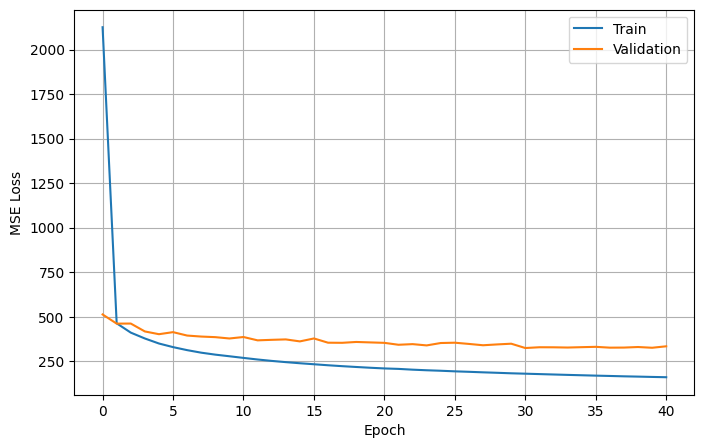

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()

plt.grid()

plt.show()

In [10]:
from models.train import evaluate_model
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 11.07 mmHg
SBP Variance : 126.75 mmHg²
SBP Std Dev  : 11.26 mmHg

DBP MAE      : 6.04 mmHg
DBP Variance : 43.58 mmHg²
DBP Std Dev  : 6.60 mmHg


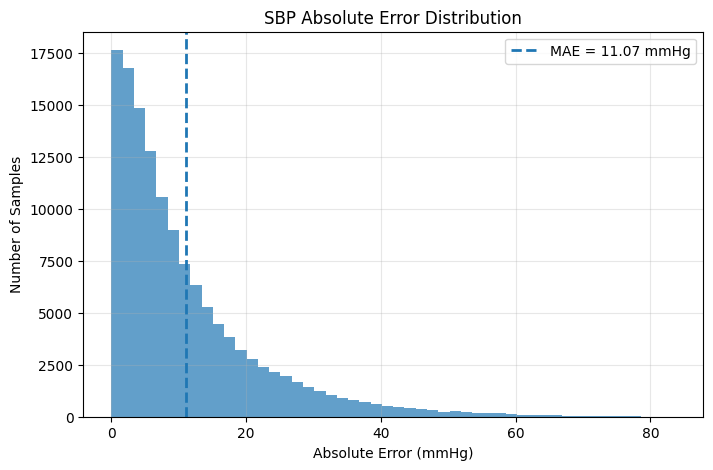

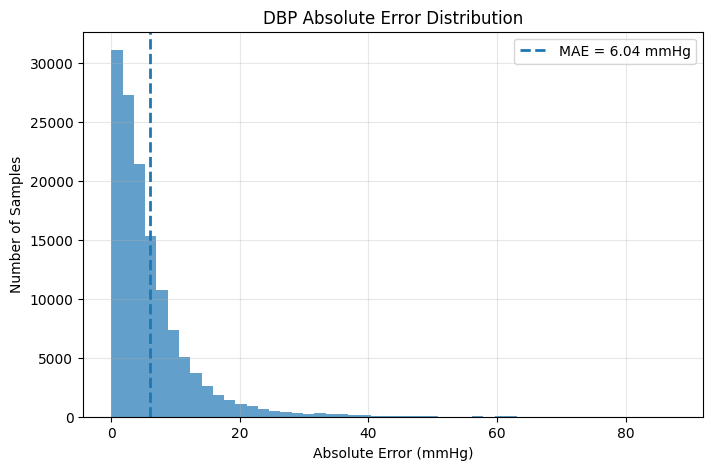


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:    184 | MAE: 31.79 mmHg
80–100 mmHg | Samples:  10342 | MAE: 15.88 mmHg
100–120 mmHg | Samples:  36971 | MAE: 9.09 mmHg
120–140 mmHg | Samples:  42591 | MAE: 8.35 mmHg
140–160 mmHg | Samples:  29783 | MAE: 11.31 mmHg
160–180 mmHg | Samples:  11086 | MAE: 17.94 mmHg
180–200 mmHg | Samples:   2884 | MAE: 28.97 mmHg
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


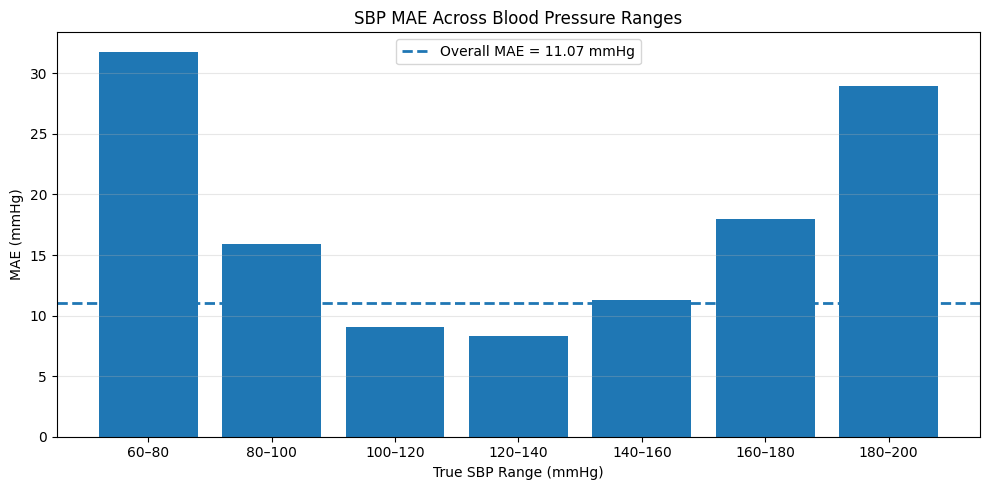


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      0 | MAE: N/A
50–60 mmHg | Samples:  41517 | MAE: 5.18 mmHg
60–70 mmHg | Samples:  47684 | MAE: 3.74 mmHg
70–80 mmHg | Samples:  26978 | MAE: 6.52 mmHg
80–90 mmHg | Samples:  12397 | MAE: 9.48 mmHg
90–100 mmHg | Samples:   3362 | MAE: 16.97 mmHg
100–110 mmHg | Samples:   1219 | MAE: 26.71 mmHg
110–120 mmHg | Samples:    396 | MAE: 39.70 mmHg
120–130 mmHg | Samples:    186 | MAE: 49.74 mmHg
130–140 mmHg | Samples:     56 | MAE: 53.27 mmHg
140–150 mmHg | Samples:     46 | MAE: 72.09 mmHg


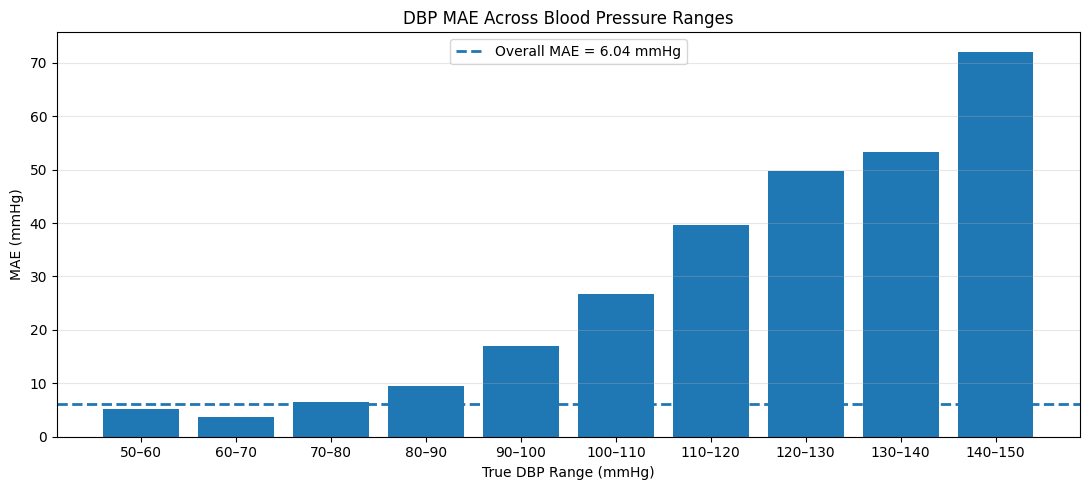

In [11]:
plot_mae(results)

## Zero - Shot learning on VitalDB dataset ##

In [26]:
import glob
class VitalDBCheckpointDataset(Dataset):

    def __init__(self, checkpoint_dir):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    checkpoint_dir,
                    "case_*.npz"
                )
            )
        )

        if len(self.files) == 0:
            raise ValueError(
                f"No checkpoint files found in: "
                f"{checkpoint_dir}"
            )

        print(
            "Checkpoint files found:",
            len(self.files)
        )

        # -----------------------------------------
        # Store number of windows in each case
        # -----------------------------------------

        self.lengths = []

        for file_path in self.files:

            data = np.load(file_path)

            self.lengths.append(
                len(data["X"])
            )

        # -----------------------------------------
        # Cumulative lengths
        # -----------------------------------------

        self.cumulative_lengths = np.cumsum(
            self.lengths
        )

        self.total_samples = int(
            self.cumulative_lengths[-1]
        )

        print(
            "Total test windows:",
            self.total_samples
        )

    def __len__(self):

        return self.total_samples

    def __getitem__(self, idx):

        # -----------------------------------------
        # Find which case contains this sample
        # -----------------------------------------

        file_idx = np.searchsorted(
            self.cumulative_lengths,
            idx,
            side="right"
        )

        if file_idx == 0:

            local_idx = idx

        else:

            local_idx = (
                idx -
                self.cumulative_lengths[file_idx - 1]
            )

        file_path = self.files[file_idx]

        # -----------------------------------------
        # Load case
        # -----------------------------------------

        data = np.load(file_path)

        X = data["X"][local_idx]
        y = data["y"][local_idx]

        # -----------------------------------------
        # Add channel dimension
        # (1000,) -> (1, 1000)
        # -----------------------------------------

        X = X[None, :]

        # -----------------------------------------
        # Convert to tensors
        # -----------------------------------------

        X = torch.tensor(
            X,
            dtype=torch.float32
        )

        y = torch.tensor(
            y,
            dtype=torch.float32
        )

        return X, y

from torch.utils.data import Subset

def load_vitaldb_test_loader(
    checkpoint_dir="/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/vitaldb_checkpoints",
    batch_size=1024,
    num_workers=4
):
    test_dataset = VitalDBCheckpointDataset(checkpoint_dir)

    # Take only first 10 samples
    test_dataset = Subset(test_dataset, range(100))

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    print("Number of test samples:", len(test_dataset))
    print("Number of test batches:", len(test_loader))
    return test_loader

In [27]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 42.61 mmHg
SBP Variance : 177.10 mmHg²
SBP Std Dev  : 13.31 mmHg

DBP MAE      : 8.81 mmHg
DBP Variance : 40.80 mmHg²
DBP Std Dev  : 6.39 mmHg


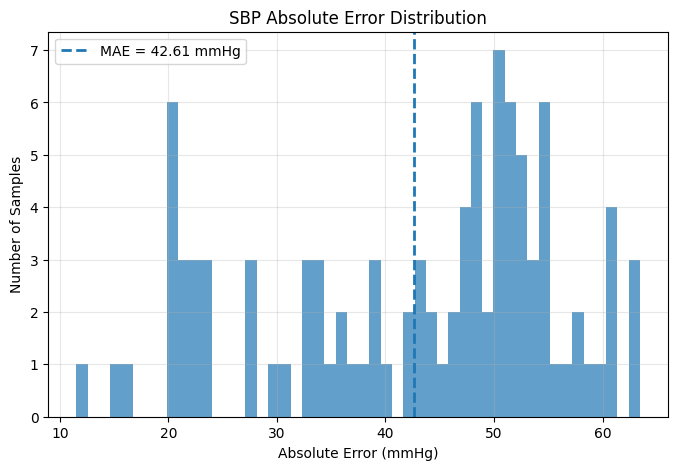

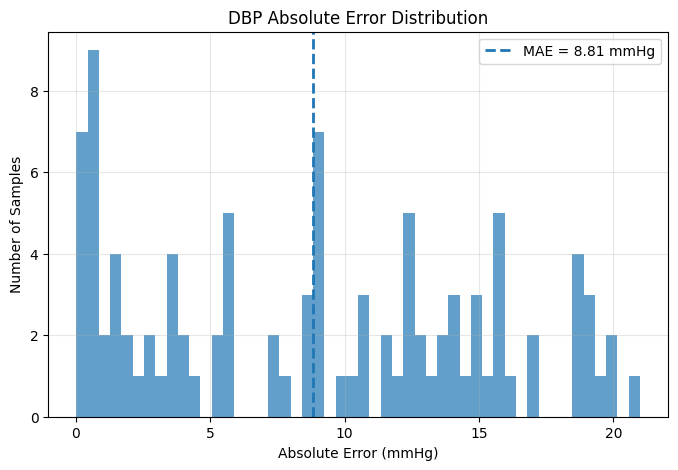


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 21.84 mmHg
140–160 mmHg | Samples:     38 | MAE: 42.07 mmHg
160–180 mmHg | Samples:     40 | MAE: 54.54 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


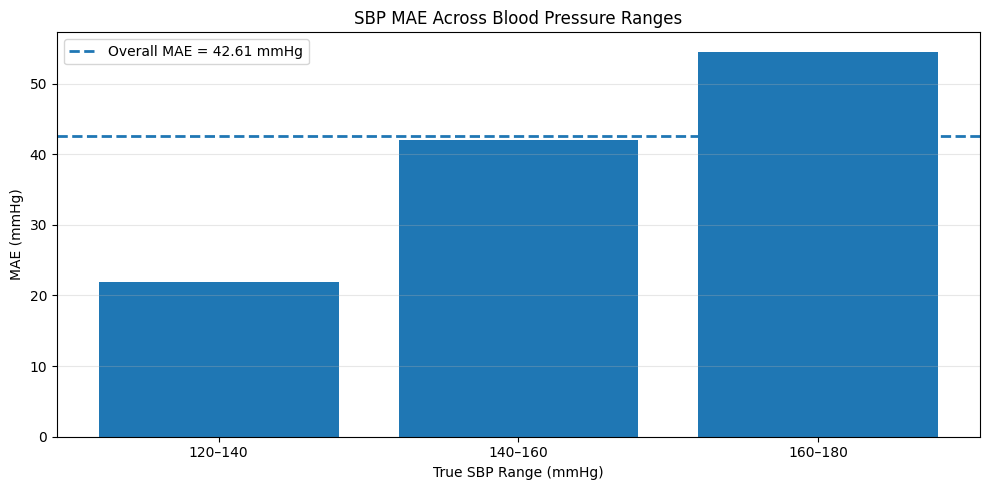


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 12.41 mmHg
50–60 mmHg | Samples:     35 | MAE: 1.65 mmHg
60–70 mmHg | Samples:     35 | MAE: 9.39 mmHg
70–80 mmHg | Samples:     28 | MAE: 16.76 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


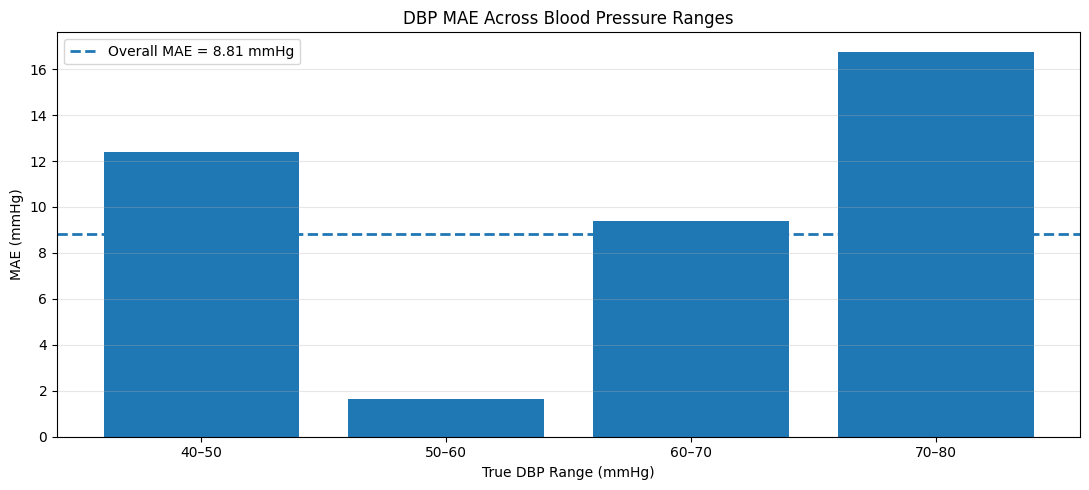

In [28]:
plot_mae(results)

Added dropout and weight decay to the model

In [29]:
from models.CNN1D import CNN1D
from models.CNN_LSTM import CNN_LSTM_Dropout

model = CNN_LSTM_Dropout().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [30]:
from models.train import train_model
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 2636.38 (SBP RMSE: 45.59, DBP RMSE: 23.62) | Val MSE: 624.17 (SBP RMSE: 22.36, DBP RMSE: 11.14) | Improved
Epoch 2/50 | Train MSE: 1265.59 (SBP RMSE: 31.52, DBP RMSE: 16.50) | Val MSE: 547.50 (SBP RMSE: 20.83, DBP RMSE: 10.66) | Improved
Epoch 3/50 | Train MSE: 1171.17 (SBP RMSE: 30.27, DBP RMSE: 15.96) | Val MSE: 563.06 (SBP RMSE: 21.10, DBP RMSE: 10.86) | No improvement (1/10)
Epoch 4/50 | Train MSE: 1073.69 (SBP RMSE: 28.94, DBP RMSE: 15.36) | Val MSE: 513.13 (SBP RMSE: 20.12, DBP RMSE: 10.41) | Improved
Epoch 5/50 | Train MSE: 1012.08 (SBP RMSE: 28.06, DBP RMSE: 14.98) | Val MSE: 505.18 (SBP RMSE: 19.90, DBP RMSE: 10.44) | Improved
Epoch 6/50 | Train MSE: 965.58 (SBP RMSE: 27.39, DBP RMSE: 14.67) | Val MSE: 467.59 (SBP RMSE: 19.09, DBP RMSE: 10.16) | Improved
Epoch 7/50 | Train MSE: 933.69 (SBP RMSE: 26.91, DBP RMSE: 14.48) | Val MSE: 470.38 (SBP RMSE: 19.17, DBP RMSE: 10.15) | No improvement (1/10)
Epoch 8/50 | Train MSE: 908.62 (SBP RMSE: 26.53, DBP RMSE: 

In [31]:
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 42.07 mmHg
SBP Variance : 81.96 mmHg²
SBP Std Dev  : 9.05 mmHg

DBP MAE      : 6.52 mmHg
DBP Variance : 21.66 mmHg²
DBP Std Dev  : 4.65 mmHg


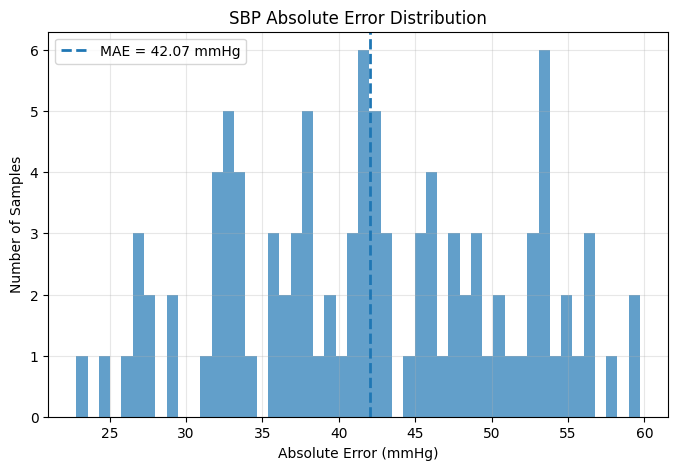

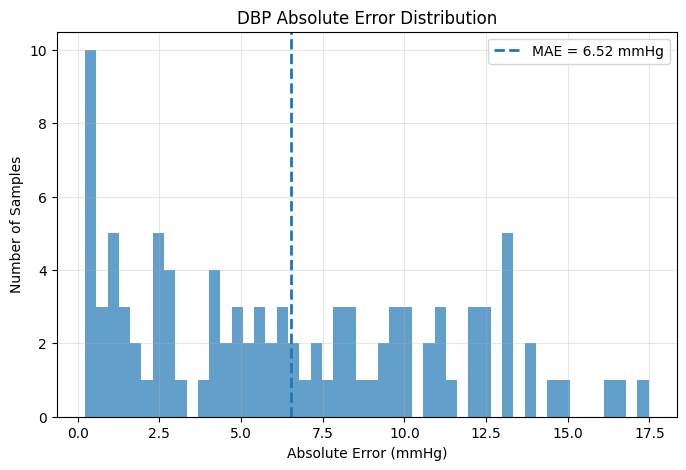


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 33.17 mmHg
140–160 mmHg | Samples:     38 | MAE: 44.04 mmHg
160–180 mmHg | Samples:     40 | MAE: 45.10 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


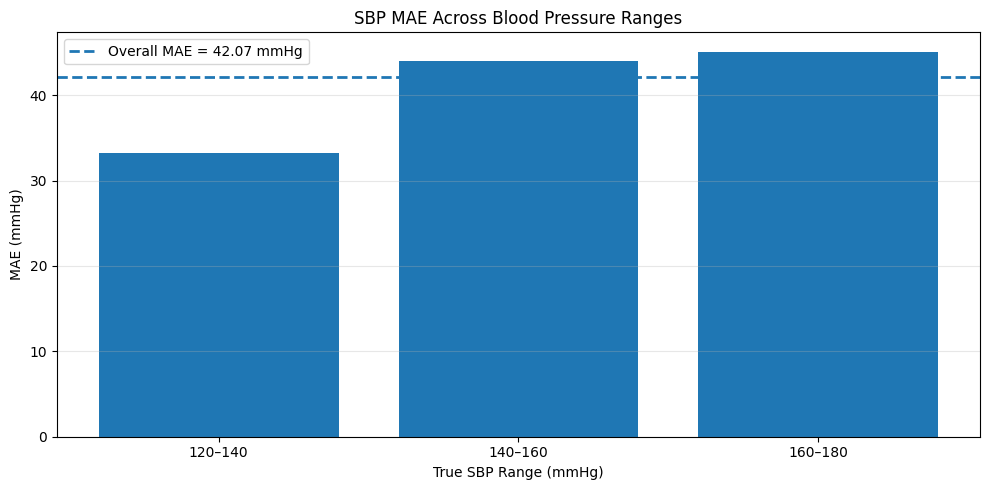


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 14.42 mmHg
50–60 mmHg | Samples:     35 | MAE: 1.77 mmHg
60–70 mmHg | Samples:     35 | MAE: 7.49 mmHg
70–80 mmHg | Samples:     28 | MAE: 10.67 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


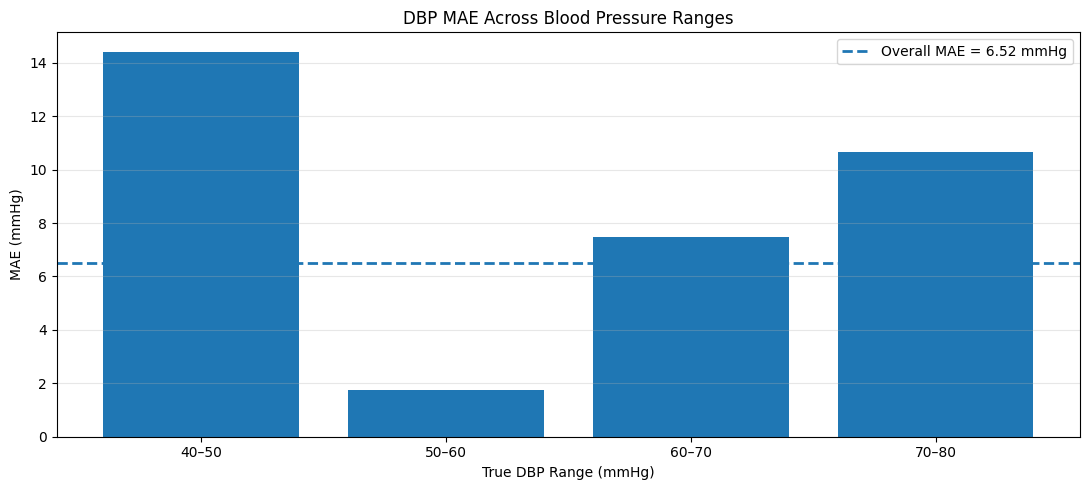

In [32]:
plot_mae(results)

In [33]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 42.07 mmHg
SBP Variance : 81.96 mmHg²
SBP Std Dev  : 9.05 mmHg

DBP MAE      : 6.52 mmHg
DBP Variance : 21.66 mmHg²
DBP Std Dev  : 4.65 mmHg


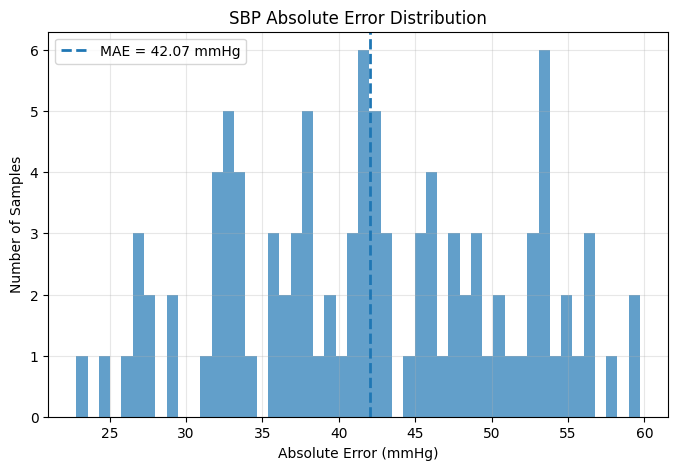

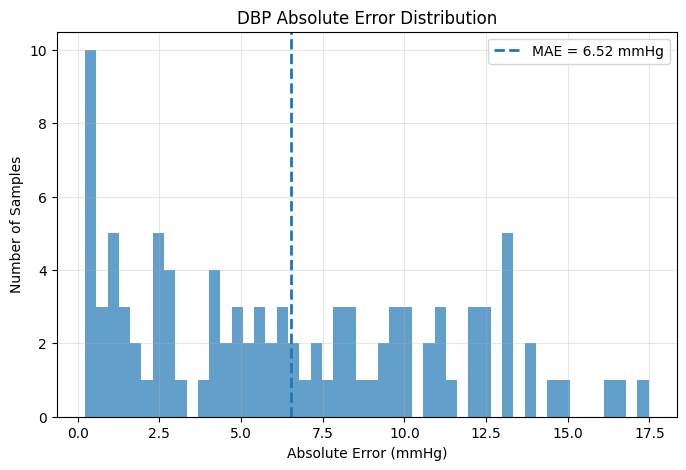


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 33.17 mmHg
140–160 mmHg | Samples:     38 | MAE: 44.04 mmHg
160–180 mmHg | Samples:     40 | MAE: 45.10 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


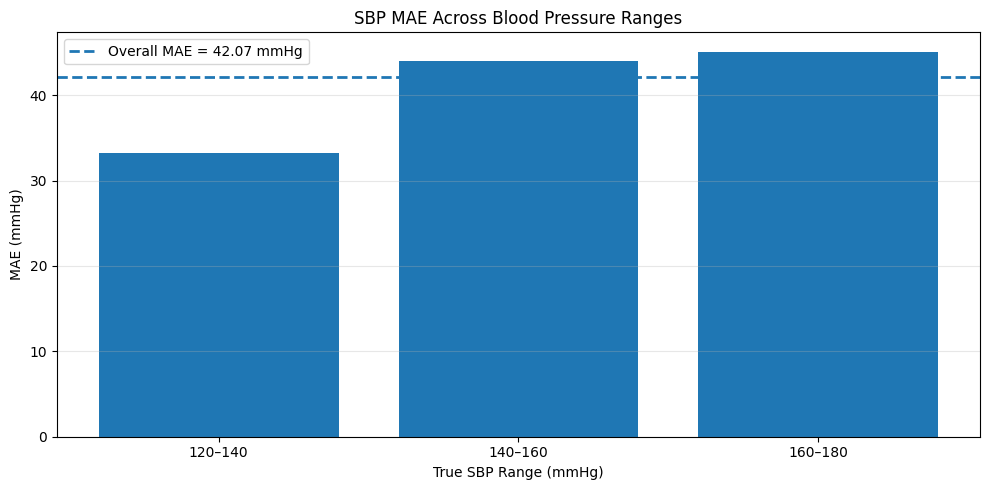


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 14.42 mmHg
50–60 mmHg | Samples:     35 | MAE: 1.77 mmHg
60–70 mmHg | Samples:     35 | MAE: 7.49 mmHg
70–80 mmHg | Samples:     28 | MAE: 10.67 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


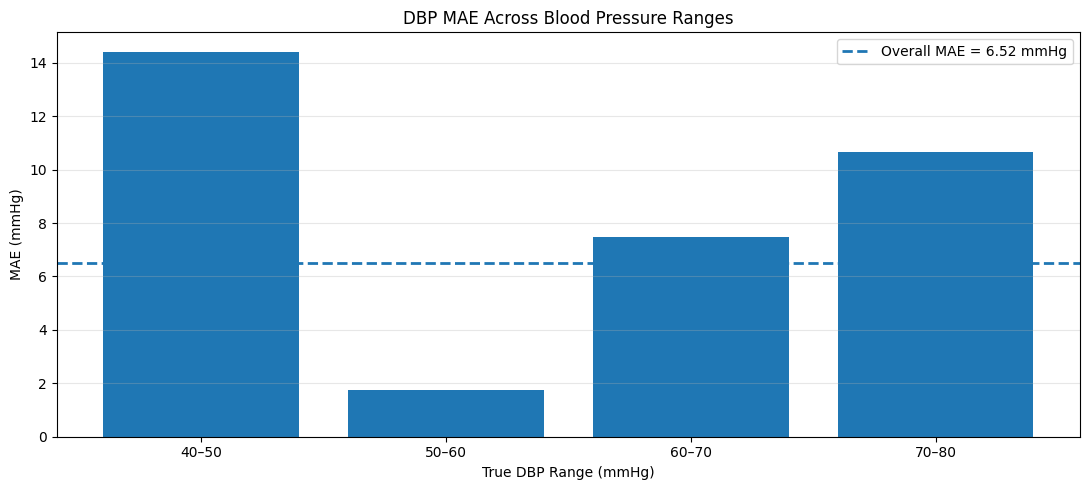

In [34]:
plot_mae(results)

**Still overfitting**

-Trying to normalise target and then check

In [35]:
model = CNN_LSTM_Dropout().to(device)

criterion = torch.nn.MSELoss()
# criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [36]:
# Mean and standard deviation of BP targets

y_mean = y_train.mean(axis=0)

y_std = y_train.std(axis=0)


print("SBP mean:", y_mean[0])
print("SBP std :", y_std[0])

print("DBP mean:", y_mean[1])
print("DBP std :", y_std[1])

SBP mean: tensor(129.5934)
SBP std : tensor(22.2738)
DBP mean: tensor(66.7786)
DBP std : tensor(11.2347)


In [37]:
y_train_norm = (
    y_train - y_mean
) / y_std


y_val_norm = (
    y_val - y_mean
) / y_std


y_test_norm = (
    y_test - y_mean
) / y_std

In [38]:
y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)

/tmp/ipykernel_766442/2247437078.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor_norm = torch.tensor(y_train_norm, dtype=torch.float32)
/tmp/ipykernel_766442/2247437078.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val_tensor_norm = torch.tensor(y_val_norm, dtype=torch.float32)
/tmp/ipykernel_766442/2247437078.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor_norm = torch.tensor(y_test_norm, dtype=torch.float32)


In [39]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train_norm, X_val, y_val_norm, X_test, y_test_norm)

In [40]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1.81 (SBP RMSE: 0.94, DBP RMSE: 0.97) | Val MSE: 1.63 (SBP RMSE: 0.92, DBP RMSE: 0.89) | Improved
Epoch 2/50 | Train MSE: 1.60 (SBP RMSE: 0.88, DBP RMSE: 0.91) | Val MSE: 1.63 (SBP RMSE: 0.91, DBP RMSE: 0.89) | No improvement (1/10)
Epoch 3/50 | Train MSE: 1.51 (SBP RMSE: 0.85, DBP RMSE: 0.88) | Val MSE: 1.48 (SBP RMSE: 0.87, DBP RMSE: 0.85) | Improved
Epoch 4/50 | Train MSE: 1.44 (SBP RMSE: 0.83, DBP RMSE: 0.86) | Val MSE: 1.47 (SBP RMSE: 0.87, DBP RMSE: 0.85) | Improved
Epoch 5/50 | Train MSE: 1.38 (SBP RMSE: 0.81, DBP RMSE: 0.85) | Val MSE: 1.39 (SBP RMSE: 0.85, DBP RMSE: 0.82) | Improved
Epoch 6/50 | Train MSE: 1.33 (SBP RMSE: 0.80, DBP RMSE: 0.83) | Val MSE: 1.49 (SBP RMSE: 0.86, DBP RMSE: 0.86) | No improvement (1/10)
Epoch 7/50 | Train MSE: 1.28 (SBP RMSE: 0.78, DBP RMSE: 0.82) | Val MSE: 1.36 (SBP RMSE: 0.83, DBP RMSE: 0.82) | Improved
Epoch 8/50 | Train MSE: 1.23 (SBP RMSE: 0.76, DBP RMSE: 0.81) | Val MSE: 1.33 (SBP RMSE: 0.83, DBP RMSE: 0.80) | Improve

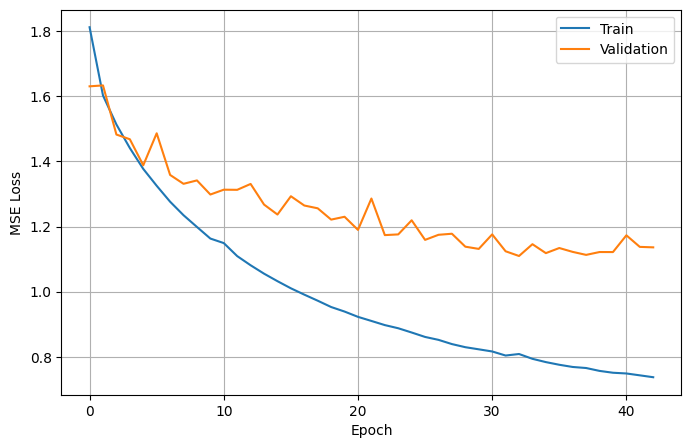

In [41]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [42]:
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 0.53 mmHg
SBP Variance : 0.27 mmHg²
SBP Std Dev  : 0.52 mmHg

DBP MAE      : 0.53 mmHg
DBP Variance : 0.36 mmHg²
DBP Std Dev  : 0.60 mmHg


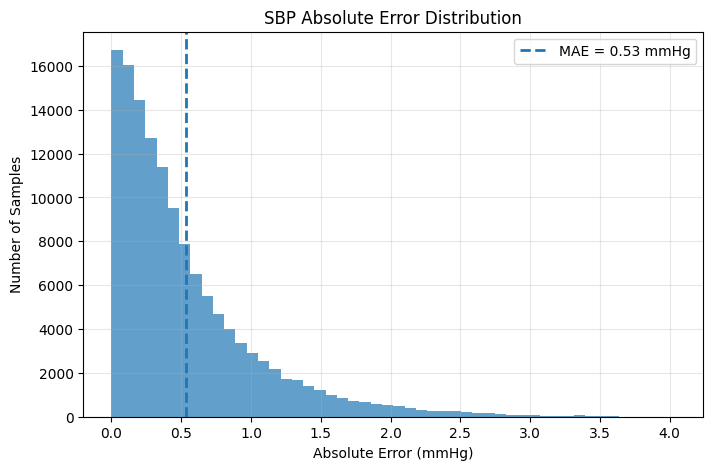

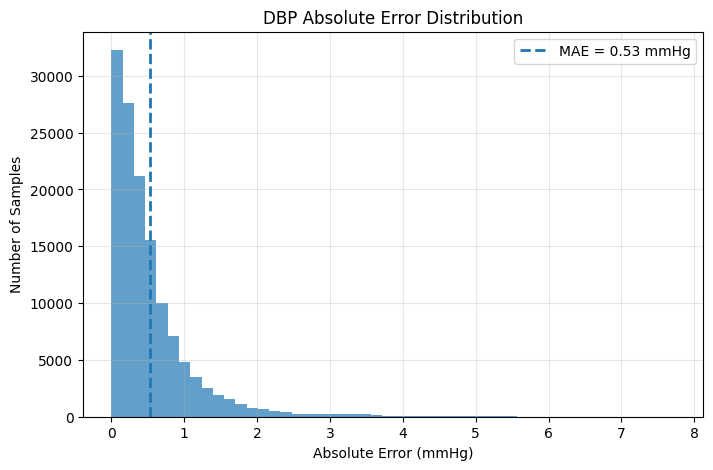


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:      0 | MAE: N/A
140–160 mmHg | Samples:      0 | MAE: N/A
160–180 mmHg | Samples:      0 | MAE: N/A
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


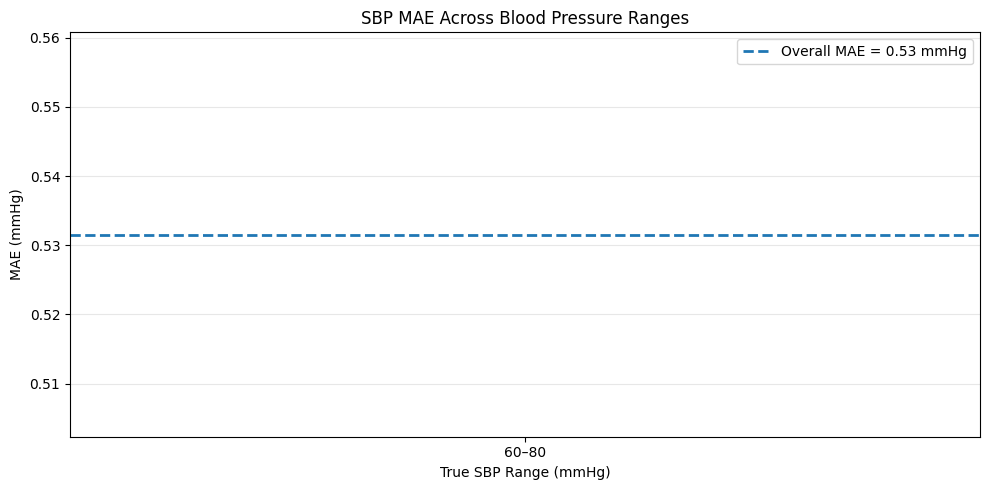


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      0 | MAE: N/A
50–60 mmHg | Samples:      0 | MAE: N/A
60–70 mmHg | Samples:      0 | MAE: N/A
70–80 mmHg | Samples:      0 | MAE: N/A
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


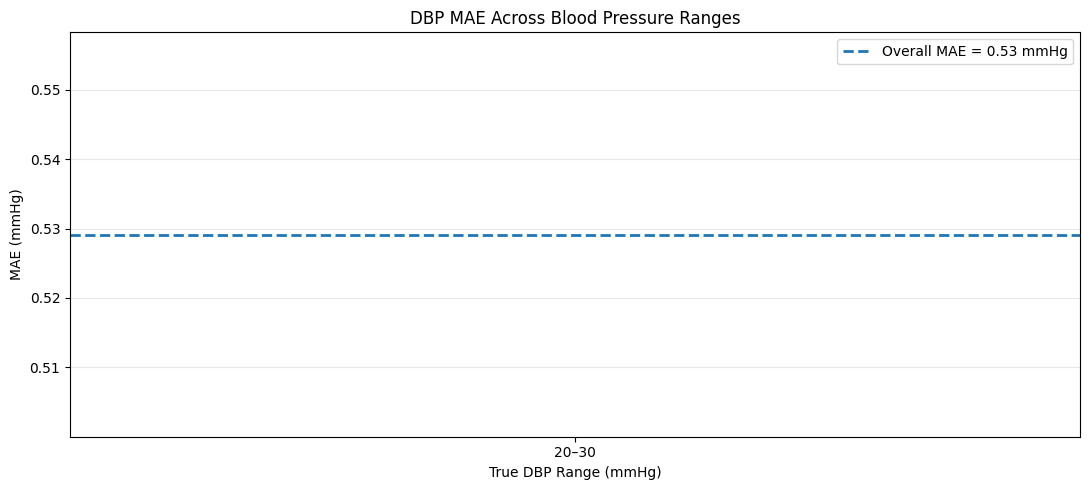

In [43]:
plot_mae(results)

In [44]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 154.20 mmHg
SBP Variance : 161.25 mmHg²
SBP Std Dev  : 12.70 mmHg

DBP MAE      : 65.24 mmHg
DBP Variance : 53.14 mmHg²
DBP Std Dev  : 7.29 mmHg


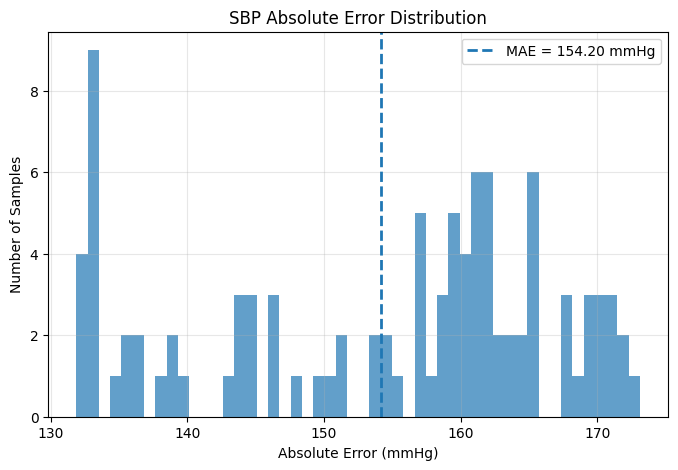

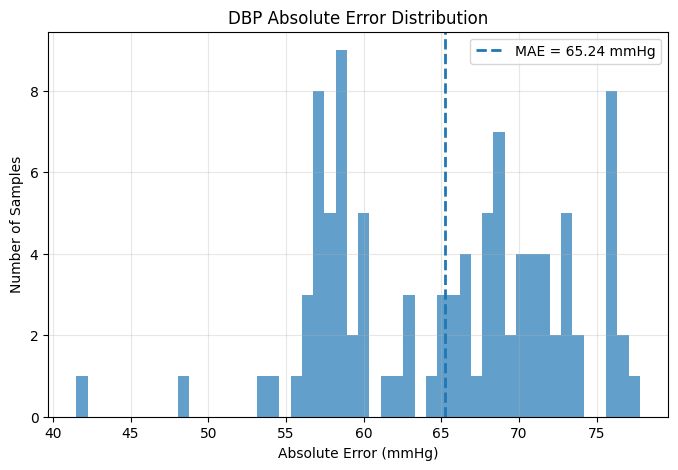


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 134.49 mmHg
140–160 mmHg | Samples:     38 | MAE: 153.35 mmHg
160–180 mmHg | Samples:     40 | MAE: 165.85 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


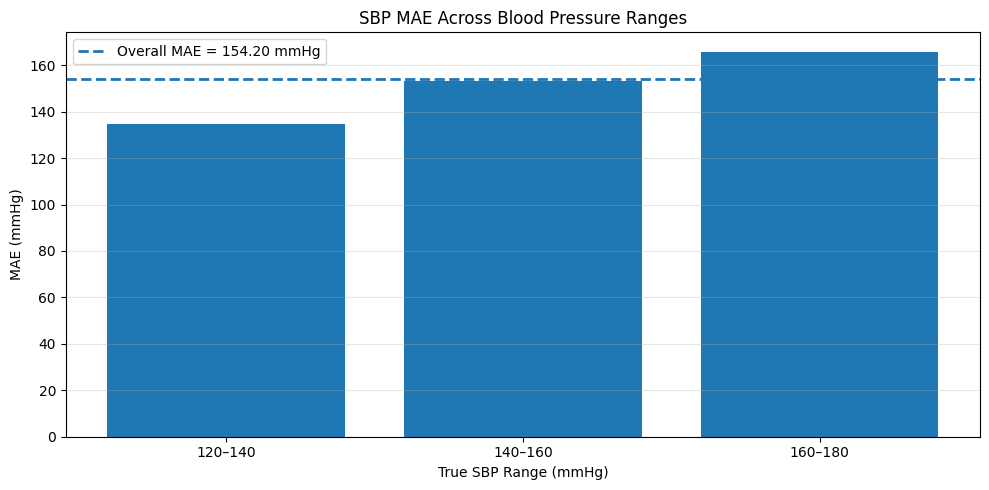


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 44.81 mmHg
50–60 mmHg | Samples:     35 | MAE: 57.85 mmHg
60–70 mmHg | Samples:     35 | MAE: 66.99 mmHg
70–80 mmHg | Samples:     28 | MAE: 73.74 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


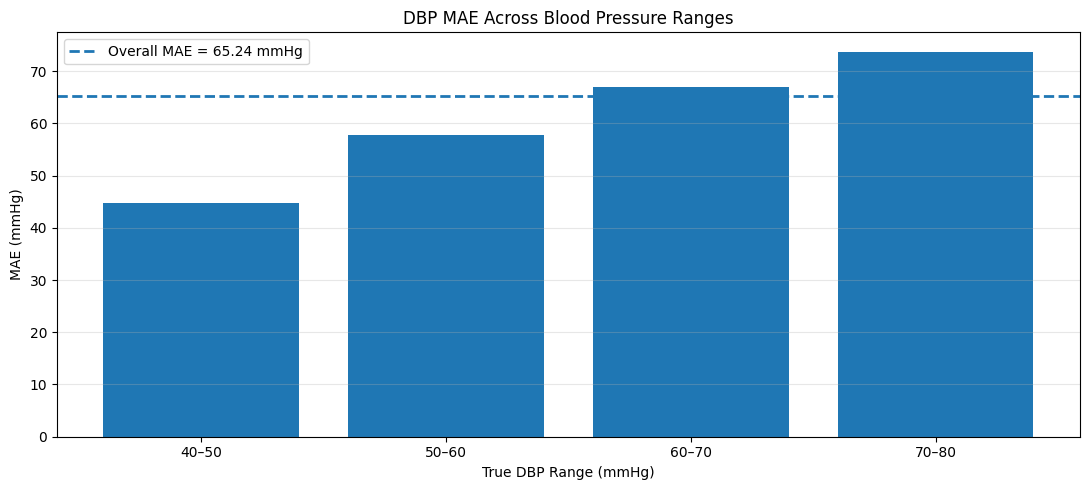

In [45]:
plot_mae(results)

## Reducing the size of the CNN ## 
(as the model is still overfitting)

- The targets are not normalized 


In [46]:
class CNN_LSTM_small(nn.Module):

    def __init__(self):

        super().__init__()


        # CNN Feature Extractor (smaller)

        self.features = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),


            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),


            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(64),
            nn.ReLU()

        )


        # LSTM

        self.lstm = nn.LSTM(

            input_size=64,   # changed from 128

            hidden_size=64,

            num_layers=2,

            batch_first=True,

            dropout=0.3

        )


        # Regression Head

        self.regressor = nn.Sequential(

            nn.Linear(64,64),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64,32),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(32,2)

        )


    def forward(self,x):

        # CNN
        x = self.features(x)

        # (batch, channels, sequence)
        # Convert for LSTM

        x = x.permute(0,2,1)

        # (batch, sequence, features)

        output, (hidden, cell) = self.lstm(x)


        # Last hidden state

        x = hidden[-1]


        x = self.regressor(x)

        return x

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM_small().to(device)
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [48]:
model, history, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)

Epoch 1/50 | Train MSE: 1.77 (SBP RMSE: 0.93, DBP RMSE: 0.95) | Val MSE: 1.57 (SBP RMSE: 0.89, DBP RMSE: 0.88) | Improved
Epoch 2/50 | Train MSE: 1.64 (SBP RMSE: 0.89, DBP RMSE: 0.92) | Val MSE: 1.63 (SBP RMSE: 0.90, DBP RMSE: 0.91) | No improvement (1/10)
Epoch 3/50 | Train MSE: 1.54 (SBP RMSE: 0.86, DBP RMSE: 0.89) | Val MSE: 1.45 (SBP RMSE: 0.86, DBP RMSE: 0.85) | Improved
Epoch 4/50 | Train MSE: 1.48 (SBP RMSE: 0.84, DBP RMSE: 0.88) | Val MSE: 1.53 (SBP RMSE: 0.87, DBP RMSE: 0.88) | No improvement (1/10)
Epoch 5/50 | Train MSE: 1.42 (SBP RMSE: 0.82, DBP RMSE: 0.86) | Val MSE: 1.43 (SBP RMSE: 0.85, DBP RMSE: 0.84) | Improved
Epoch 6/50 | Train MSE: 1.38 (SBP RMSE: 0.81, DBP RMSE: 0.85) | Val MSE: 1.46 (SBP RMSE: 0.88, DBP RMSE: 0.83) | No improvement (1/10)
Epoch 7/50 | Train MSE: 1.34 (SBP RMSE: 0.80, DBP RMSE: 0.84) | Val MSE: 1.35 (SBP RMSE: 0.82, DBP RMSE: 0.82) | Improved
Epoch 8/50 | Train MSE: 1.32 (SBP RMSE: 0.79, DBP RMSE: 0.84) | Val MSE: 1.37 (SBP RMSE: 0.84, DBP RMSE: 0.

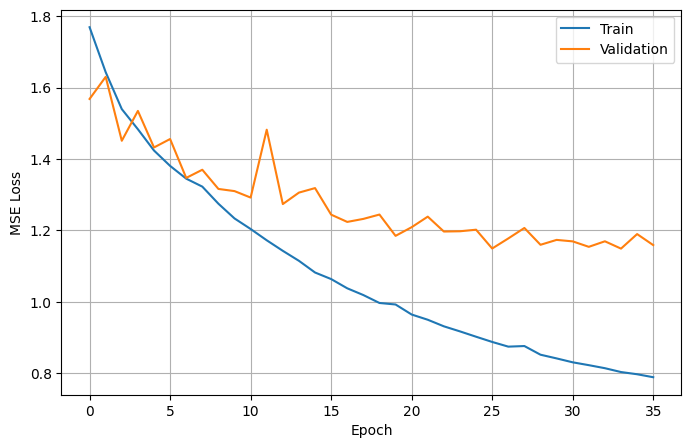

In [49]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [50]:
results = evaluate_model(
    model,
    test_loader,
    device
)


ABSOLUTE ERROR STATISTICS
SBP MAE      : 153.57 mmHg
SBP Variance : 158.21 mmHg²
SBP Std Dev  : 12.58 mmHg

DBP MAE      : 64.89 mmHg
DBP Variance : 51.85 mmHg²
DBP Std Dev  : 7.20 mmHg


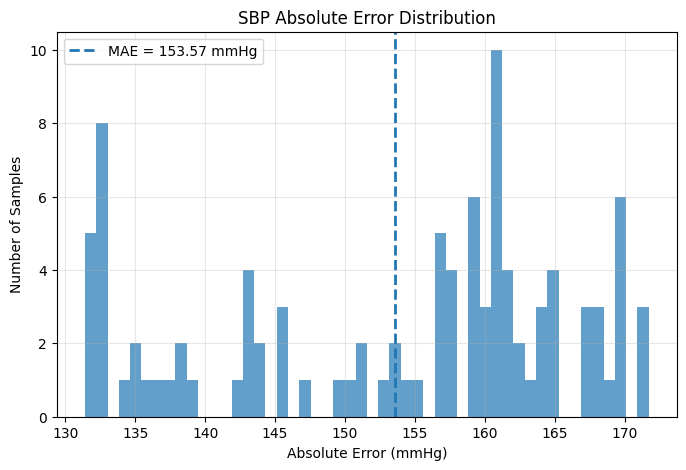

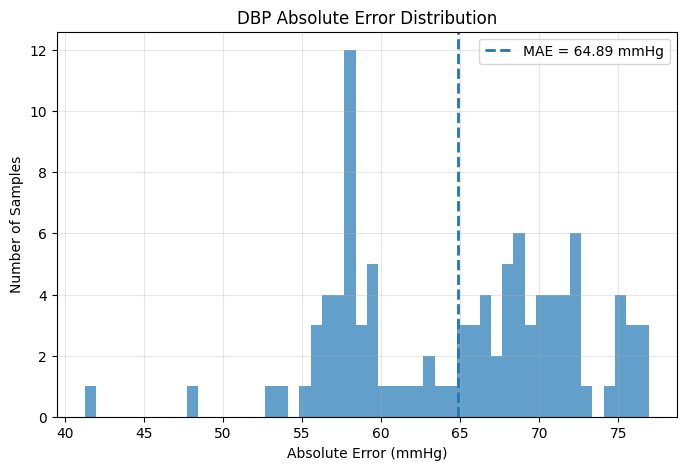


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 134.02 mmHg
140–160 mmHg | Samples:     38 | MAE: 152.79 mmHg
160–180 mmHg | Samples:     40 | MAE: 165.07 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


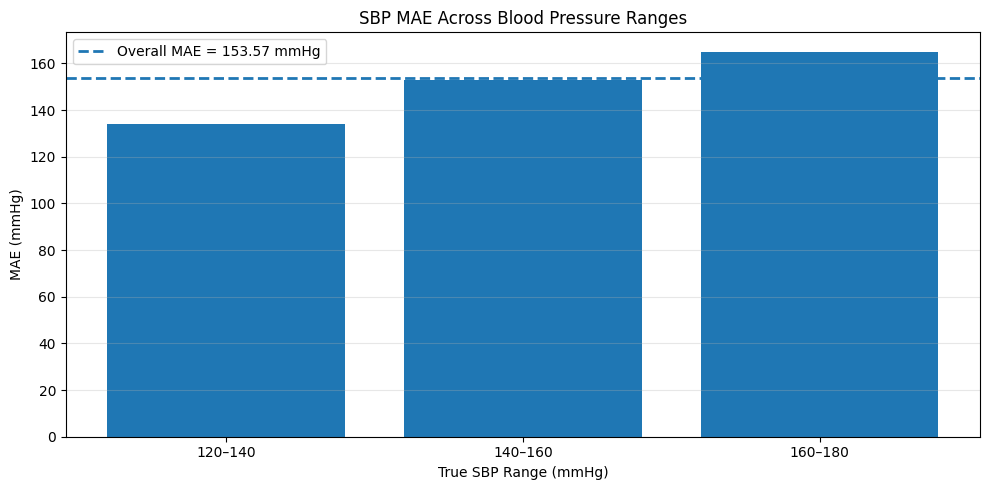


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 44.56 mmHg
50–60 mmHg | Samples:     35 | MAE: 57.59 mmHg
60–70 mmHg | Samples:     35 | MAE: 66.68 mmHg
70–80 mmHg | Samples:     28 | MAE: 73.23 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


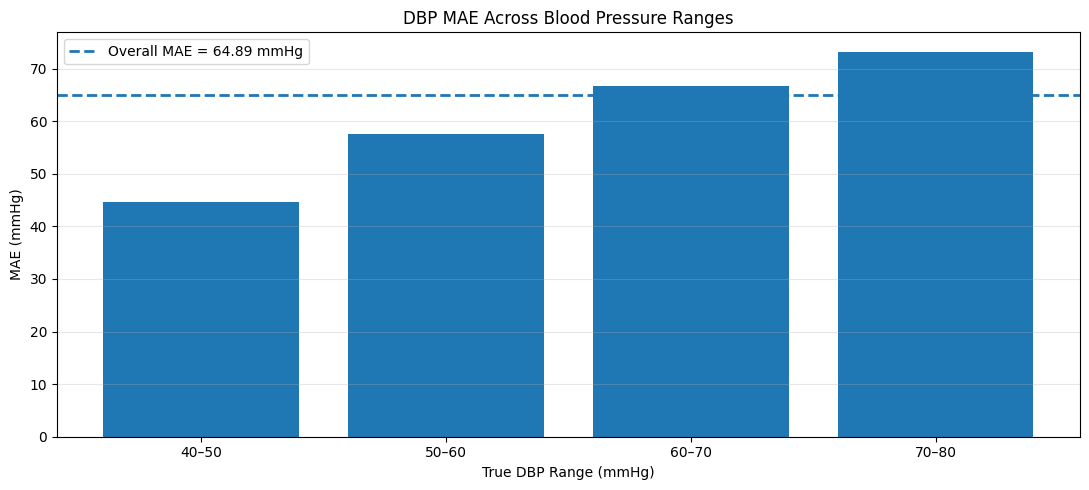

In [51]:
plot_mae(results)

In [52]:
test_loader = load_vitaldb_test_loader()

results = evaluate_model(
    model,
    test_loader,
    device
)

Checkpoint files found: 3225
Total test windows: 9717359
Number of test samples: 100
Number of test batches: 1



ABSOLUTE ERROR STATISTICS
SBP MAE      : 153.57 mmHg
SBP Variance : 158.21 mmHg²
SBP Std Dev  : 12.58 mmHg

DBP MAE      : 64.89 mmHg
DBP Variance : 51.85 mmHg²
DBP Std Dev  : 7.20 mmHg


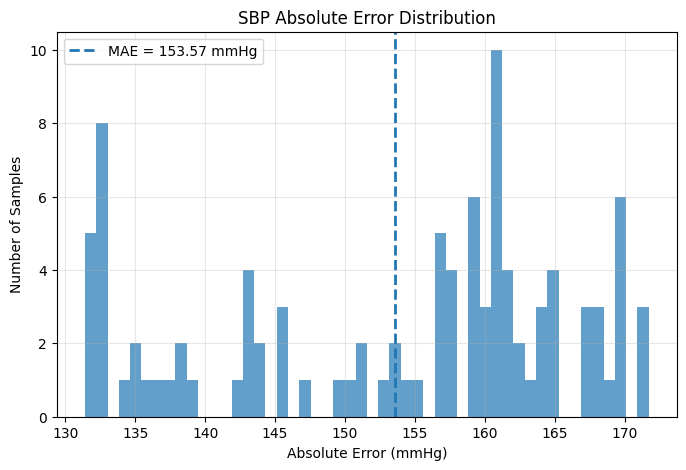

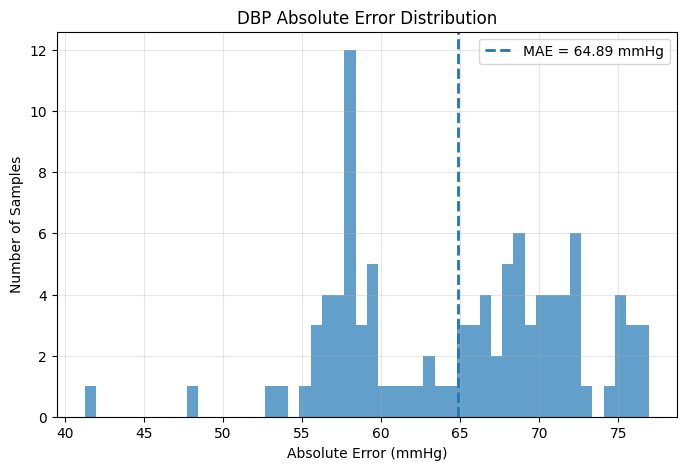


SBP MAE BY TRUE SBP RANGE
60–80 mmHg | Samples:      0 | MAE: N/A
80–100 mmHg | Samples:      0 | MAE: N/A
100–120 mmHg | Samples:      0 | MAE: N/A
120–140 mmHg | Samples:     22 | MAE: 134.02 mmHg
140–160 mmHg | Samples:     38 | MAE: 152.79 mmHg
160–180 mmHg | Samples:     40 | MAE: 165.07 mmHg
180–200 mmHg | Samples:      0 | MAE: N/A
200–220 mmHg | Samples:      0 | MAE: N/A
220–240 mmHg | Samples:      0 | MAE: N/A
240–260 mmHg | Samples:      0 | MAE: N/A


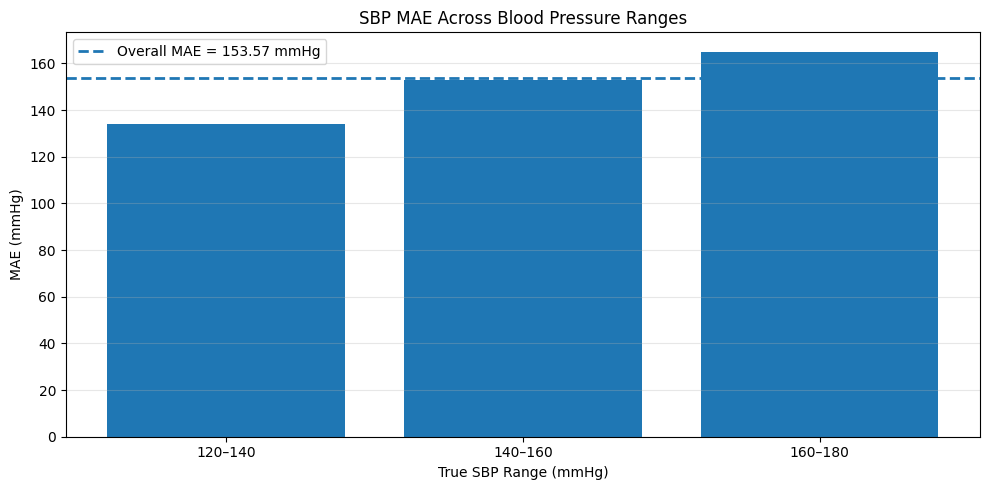


DBP MAE BY TRUE DBP RANGE
20–30 mmHg | Samples:      0 | MAE: N/A
30–40 mmHg | Samples:      0 | MAE: N/A
40–50 mmHg | Samples:      2 | MAE: 44.56 mmHg
50–60 mmHg | Samples:     35 | MAE: 57.59 mmHg
60–70 mmHg | Samples:     35 | MAE: 66.68 mmHg
70–80 mmHg | Samples:     28 | MAE: 73.23 mmHg
80–90 mmHg | Samples:      0 | MAE: N/A
90–100 mmHg | Samples:      0 | MAE: N/A
100–110 mmHg | Samples:      0 | MAE: N/A
110–120 mmHg | Samples:      0 | MAE: N/A
120–130 mmHg | Samples:      0 | MAE: N/A
130–140 mmHg | Samples:      0 | MAE: N/A
140–150 mmHg | Samples:      0 | MAE: N/A


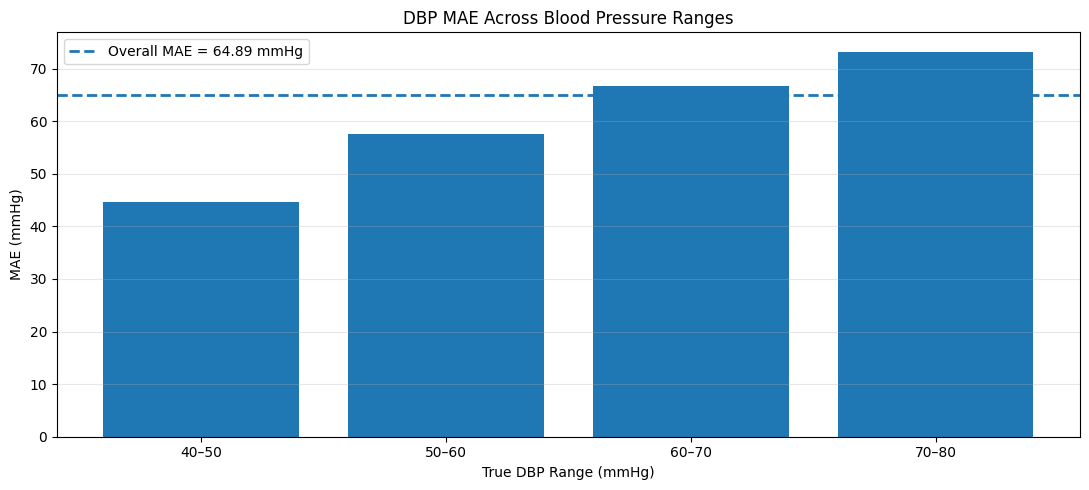

In [53]:
plot_mae(results)